<a href="https://colab.research.google.com/github/dennisgathu8/36CHAMBERS/blob/main/Afterredcardsimulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample of Synthetic Match Data (First 5 Minutes):
        Team_Possession (%)  Team_Pressing_Efficiency    Player_1    Player_2  \
Minute                                                                          
1                 51.843367                  0.520838  107.450712  101.456163   
2                 48.033306                  0.295827   97.926035  114.529675   
3                 50.143724                  0.475282  109.715328   89.469204   
4                 56.392259                  0.431802  122.845448   95.085068   
5                 50.955495                  0.399838   96.487699   94.118378   

          Player_3    Player_4    Player_5    Player_6    Player_7  \
Minute                                                               
1       109.385010  121.619099  107.790198   99.059814  112.535382   
2        87.142637   78.462068  122.991084  114.327135   83.054397   
3        83.936613  117.447456   98.368598   85.214109  107.947063   
4       107.237086  100.153496  

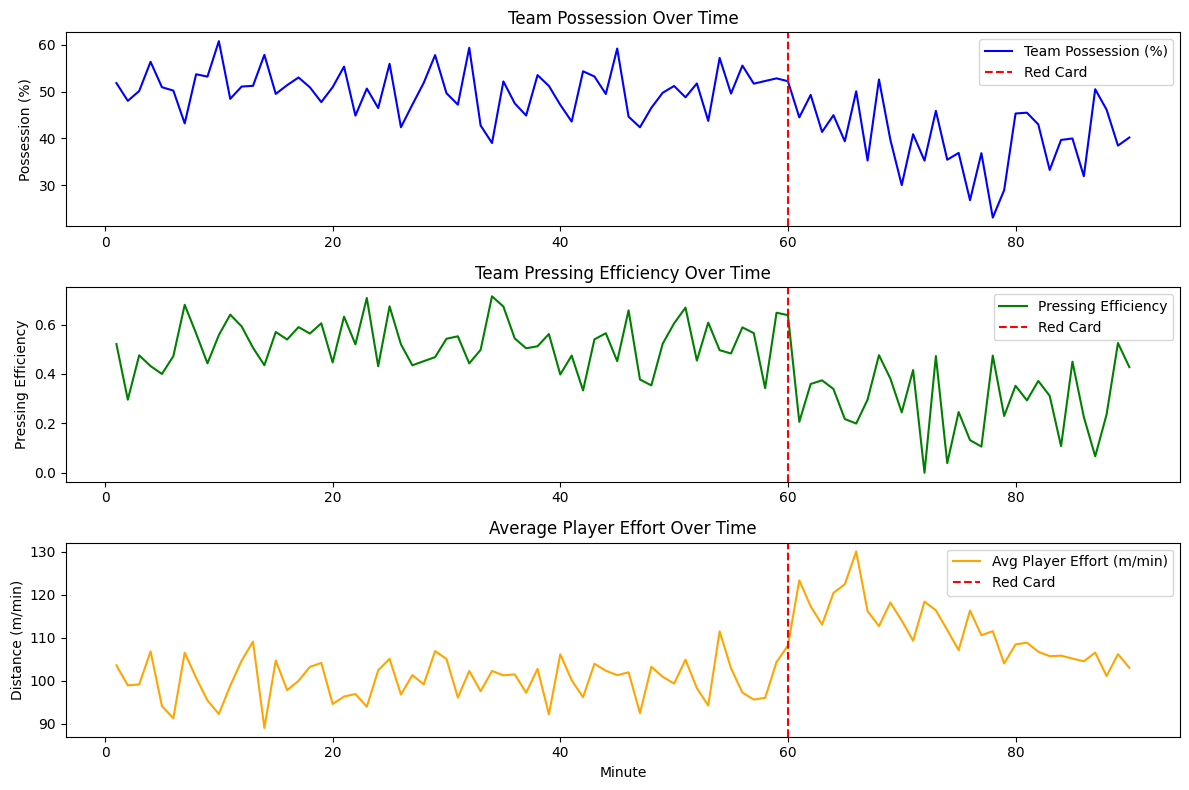

In [1]:
# Ensure inline plotting in Colab
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Define match parameters
minutes = 90  # Total match duration
red_card_minute = 60  # Red card occurs at 60 minutes
players_initial = 11
players_after_red = 10

# Simulate time series: one entry per minute
time = np.arange(1, minutes + 1)

# Function to simulate player effort (distance covered per minute, in meters)
def simulate_effort(minutes, red_card_minute, players):
    effort = np.zeros(minutes)
    # Before red card: normal effort distribution
    effort[:red_card_minute] = np.random.normal(loc=100, scale=15, size=red_card_minute)
    # After red card: increased effort with fatigue factor
    effort[red_card_minute:] = np.random.normal(loc=120, scale=20, size=minutes - red_card_minute) * (1 - 0.005 * np.arange(minutes - red_card_minute))
    return effort

# Function to simulate team possession (%)
def simulate_possession(minutes, red_card_minute):
    possession = np.zeros(minutes)
    # Before red card: balanced possession
    possession[:red_card_minute] = np.random.normal(loc=50, scale=5, size=red_card_minute)
    # After red card: reduced possession
    possession[red_card_minute:] = np.random.normal(loc=40, scale=7, size=minutes - red_card_minute)
    return np.clip(possession, 0, 100)

# Function to simulate pressing efficiency (successful presses per minute)
def simulate_pressing(minutes, red_card_minute):
    pressing = np.zeros(minutes)
    # Before red card: steady pressing
    pressing[:red_card_minute] = np.random.normal(loc=0.5, scale=0.1, size=red_card_minute)
    # After red card: reduced efficiency
    pressing[red_card_minute:] = np.random.normal(loc=0.3, scale=0.15, size=minutes - red_card_minute)
    return np.clip(pressing, 0, 1)

# Generate synthetic data for 10 players
player_effort = {f"Player_{i+1}": simulate_effort(minutes, red_card_minute, players_after_red) for i in range(players_after_red)}

# Generate team-level metrics
team_possession = simulate_possession(minutes, red_card_minute)
team_pressing = simulate_pressing(minutes, red_card_minute)

# Create a DataFrame
df_match = pd.DataFrame({
    "Minute": time,
    "Team_Possession (%)": team_possession,
    "Team_Pressing_Efficiency": team_pressing,
    **player_effort  # Unpack player effort columns
})

# Simulate the sent-off player's effort (stops at red card)
player_sent_off_effort = np.zeros(minutes)
player_sent_off_effort[:red_card_minute] = np.random.normal(loc=100, scale=15, size=red_card_minute)
df_match["Player_Sent_Off"] = player_sent_off_effort

# Set 'Minute' as index
df_match.set_index("Minute", inplace=True)

# Display sample data
print("Sample of Synthetic Match Data (First 5 Minutes):")
print(df_match.head())
print("\nAfter Red Card (Minute 61-65):")
print(df_match.loc[61:65])

# Visualize key metrics
plt.figure(figsize=(12, 8))

# Plot team possession
plt.subplot(3, 1, 1)
plt.plot(df_match.index, df_match["Team_Possession (%)"], label="Team Possession (%)", color="blue")
plt.axvline(red_card_minute, color="red", linestyle="--", label="Red Card")
plt.title("Team Possession Over Time")
plt.ylabel("Possession (%)")
plt.legend()

# Plot team pressing efficiency
plt.subplot(3, 1, 2)
plt.plot(df_match.index, df_match["Team_Pressing_Efficiency"], label="Pressing Efficiency", color="green")
plt.axvline(red_card_minute, color="red", linestyle="--", label="Red Card")
plt.title("Team Pressing Efficiency Over Time")
plt.ylabel("Pressing Efficiency")
plt.legend()

# Plot average player effort
avg_effort = df_match[[f"Player_{i+1}" for i in range(players_after_red)]].mean(axis=1)
plt.subplot(3, 1, 3)
plt.plot(df_match.index, avg_effort, label="Avg Player Effort (m/min)", color="orange")
plt.axvline(red_card_minute, color="red", linestyle="--", label="Red Card")
plt.title("Average Player Effort Over Time")
plt.ylabel("Distance (m/min)")
plt.xlabel("Minute")
plt.legend()

plt.tight_layout()
plt.show()